# Pipeline HerbalScan — Klasifikasi Daun Herbal

Notebook ini menjalankan seluruh pipeline:
1. Remove background (rembg)
2. Resize 224×224
3. Augmentasi Flip (H + V)
4. Build dataset final (no-bg & bg)
5. Visualisasi sampel
6. **Skenario 1** — BG vs No-BG, 8 kelas spesies, split 80:20 & 70:30
7. **Skenario 2** — Kondisi daun Sehat vs Rusak, split 80:20
8. Ringkasan hasil

**Augmentasi offline** (`augment.py`): 167 H-Flip + 167 V-Flip + 166 Random Rotate → 500 per kelas
**Augmentasi training** (transform): Rotasi kotak acak (0°/90°/180°/270°) + H-Flip
**Skenario 2 tambahan**: GaussianBlur(k=3) untuk robustness daun rusak

In [2]:
import json, time, random, shutil
import cv2
import torch
import torch.nn as nn
import numpy as np
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from rembg import remove as rembg_remove
from torchvision import datasets, transforms, models
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix

BASE_DIR = Path().resolve()
if BASE_DIR.name == 'training':
    BASE_DIR = BASE_DIR.parent  
DATA_DIR      = BASE_DIR / "data"
NOBG_DIR      = DATA_DIR / "nobg"
RESIZED_DIR   = DATA_DIR / "resized"
AUGMENTED_DIR = DATA_DIR / "augmented"
FINAL_NOBG    = DATA_DIR / "final"
FINAL_BG      = DATA_DIR / "final bg"
MODEL_DIR     = BASE_DIR / "model"
RESULT_DIR    = BASE_DIR / "results"

BATCH_SIZE = 16
EPOCHS     = 10
LR         = 0.001
SEED       = 42
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for d in [MODEL_DIR, RESULT_DIR]:
    d.mkdir(exist_ok=True)

print(f"Device: {DEVICE}")

c:\Users\dvsw1\Documents\Kuliah\Kuliah\Skripsi\Code\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu


## Transforms & Helper Functions

In [3]:
# ── Transform Skenario 1 (spesies) ────────────────────────────────────────────
transform_train_s1 = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Lambda(lambda img: TF.rotate(img, random.choice([0, 90, 180, 270]))),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

# ── Transform Skenario 2 (kondisi) ────────────────────────────────────────────
# GaussianBlur → robust terhadap daun yang lebih rusak/buram dari dataset
transform_train_s2 = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Lambda(lambda img: TF.rotate(img, random.choice([0, 90, 180, 270]))),
    transforms.RandomHorizontalFlip(),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

# ── Transform validasi (tanpa augmentasi) ────────────────────────────────────
transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])


class TransformWrapper(Dataset):
    def __init__(self, subset: Subset, transform):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        img, label = self.subset[idx]
        return self.transform(img), label


def load_species_only(dataset_path: Path):
    full = datasets.ImageFolder(str(dataset_path))
    valid_idx  = [i for i, name in enumerate(full.classes) if "rusak" not in name.lower()]
    valid_set  = set(valid_idx)
    old_to_new = {old: new for new, old in enumerate(valid_idx)}
    full.samples      = [(p, old_to_new[c]) for p, c in full.samples if c in valid_set]
    full.targets      = [c for _, c in full.samples]
    full.classes      = [full.classes[i] for i in valid_idx]
    full.class_to_idx = {name: i for i, name in enumerate(full.classes)}
    return full, full.classes


def folder_ready(path: Path, min_files: int = 1) -> bool:
    return path.exists() and sum(1 for _ in path.rglob("*") if _.is_file()) >= min_files

print("Transforms & helpers siap.")

Transforms & helpers siap.


## 1. Remove Background (rembg)

In [4]:
if folder_ready(NOBG_DIR):
    print(f"Skip — {NOBG_DIR} sudah ada.")
else:
    NOBG_DIR.mkdir(parents=True, exist_ok=True)
    raw_dir = DATA_DIR / "raw"
    exts = {".jpg", ".jpeg", ".png"}
    total = 0
    for cls_dir in sorted(raw_dir.iterdir()):
        if not cls_dir.is_dir():
            continue
        out_cls = NOBG_DIR / cls_dir.name
        out_cls.mkdir(exist_ok=True)
        for img_file in cls_dir.iterdir():
            if img_file.suffix.lower() not in exts:
                continue
            with open(img_file, "rb") as f:
                result = rembg_remove(f.read())
            out_path = out_cls / (img_file.stem + ".png")
            out_path.write_bytes(result)
            total += 1
    print(f"Remove background selesai — {total} gambar → {NOBG_DIR}")

Skip — C:\Users\dvsw1\Documents\Kuliah\Kuliah\Skripsi\Code\data\nobg sudah ada.


## 2. Resize 224×224

In [5]:
if folder_ready(RESIZED_DIR):
    print(f"Skip — {RESIZED_DIR} sudah ada.")
else:
    RESIZED_DIR.mkdir(parents=True, exist_ok=True)
    exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    total = 0
    for cls_dir in sorted(NOBG_DIR.iterdir()):
        if not cls_dir.is_dir():
            continue
        out_cls = RESIZED_DIR / cls_dir.name
        out_cls.mkdir(exist_ok=True)
        for img_file in cls_dir.iterdir():
            if img_file.suffix.lower() not in exts:
                continue
            img = cv2.imread(str(img_file), cv2.IMREAD_UNCHANGED)
            if img is None:
                continue
            img_resized = cv2.resize(img, (224, 224))
            cv2.imwrite(str(out_cls / img_file.name), img_resized)
            total += 1
    print(f"Resize selesai — {total} gambar → {RESIZED_DIR}")

Skip — C:\Users\dvsw1\Documents\Kuliah\Kuliah\Skripsi\Code\data\resized sudah ada.


## 3. Augmentasi Flip (Horizontal + Vertical)

In [6]:
if folder_ready(AUGMENTED_DIR):
    print(f"Skip — {AUGMENTED_DIR} sudah ada.")
else:
    AUGMENTED_DIR.mkdir(parents=True, exist_ok=True)
    AUG_H_FLIP = 167
    AUG_V_FLIP = 167
    AUG_ROTATE = 166
    MAX_ANGLE  = 30
    exts = {".jpg", ".jpeg", ".png"}
    total = 0

    def _rotate(img, angle):
        h, w = img.shape[:2]
        M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
        return cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT)

    for cls_dir in sorted(RESIZED_DIR.iterdir()):
        if not cls_dir.is_dir():
            continue
        out_cls = AUGMENTED_DIR / cls_dir.name
        out_cls.mkdir(exist_ok=True)
        images = [p for p in cls_dir.iterdir() if p.suffix.lower() in exts]
        if not images:
            continue

        for i in range(AUG_H_FLIP):
            img = cv2.imread(str(random.choice(images)))
            if img is not None:
                cv2.imwrite(str(out_cls / f"{cls_dir.name}_hflip_{i}.jpg"), cv2.flip(img, 1))
                total += 1

        for i in range(AUG_V_FLIP):
            img = cv2.imread(str(random.choice(images)))
            if img is not None:
                cv2.imwrite(str(out_cls / f"{cls_dir.name}_vflip_{i}.jpg"), cv2.flip(img, 0))
                total += 1

        for i in range(AUG_ROTATE):
            img = cv2.imread(str(random.choice(images)))
            if img is not None:
                angle = random.uniform(-MAX_ANGLE, MAX_ANGLE)
                cv2.imwrite(str(out_cls / f"{cls_dir.name}_rot_{i}_{angle:.1f}deg.jpg"), _rotate(img, angle))
                total += 1

        print(f"  {cls_dir.name}: {AUG_H_FLIP + AUG_V_FLIP + AUG_ROTATE} augmented")

    print(f"Augmentasi selesai — {total} gambar → {AUGMENTED_DIR}")

Skip — C:\Users\dvsw1\Documents\Kuliah\Kuliah\Skripsi\Code\data\augmented sudah ada.


## 4. Build Final Dataset (No-BG & BG)

Menggabungkan `data/resized` + `data/augmented` → `data/final` (no-bg)
Dataset `data/final bg` diasumsikan sudah tersedia (gambar asli dengan background).

In [7]:
def build_nobg_final():
    if folder_ready(FINAL_NOBG):
        print(f"Skip — {FINAL_NOBG} sudah ada.")
        return
    FINAL_NOBG.mkdir(parents=True, exist_ok=True)
    sources = [RESIZED_DIR, AUGMENTED_DIR]
    total = 0
    for src in sources:
        if not src.exists():
            print(f"  Warning: {src} tidak ditemukan, dilewati")
            continue
        for cls_dir in sorted(src.iterdir()):
            if not cls_dir.is_dir():
                continue
            out_cls = FINAL_NOBG / cls_dir.name
            out_cls.mkdir(exist_ok=True)
            for img_file in cls_dir.iterdir():
                if img_file.is_file():
                    dst = out_cls / f"{src.name}_{img_file.name}"
                    shutil.copy2(img_file, dst)
                    total += 1
    print(f"Build final no-bg selesai — {total} file → {FINAL_NOBG}")

build_nobg_final()

Skip — C:\Users\dvsw1\Documents\Kuliah\Kuliah\Skripsi\Code\data\final sudah ada.


## 5. Skenario 1 — Pelatihan BG vs No-BG (8 Kelas Spesies)

Folder 'Rusak' **dikecualikan** — hanya 8 kelas spesies yang dilatih.
Split: 80:20 dan 70:30 (Stratified Shuffle Split)


NOBG | Split 80:20 | 8 kelas | Train=5120 Val=1280
  Epoch 1/10  train_loss=1.6747  val_loss=1.1875  val_acc=0.9930
  Epoch 2/10  train_loss=1.0817  val_loss=0.6994  val_acc=0.9953
  Epoch 3/10  train_loss=0.7487  val_loss=0.4464  val_acc=0.9992
  Epoch 4/10  train_loss=0.5537  val_loss=0.3214  val_acc=0.9992
  Epoch 5/10  train_loss=0.4319  val_loss=0.2352  val_acc=0.9984
  Epoch 6/10  train_loss=0.3525  val_loss=0.1784  val_acc=0.9992
  Epoch 7/10  train_loss=0.2875  val_loss=0.1413  val_acc=0.9992
  Epoch 8/10  train_loss=0.2476  val_loss=0.1113  val_acc=0.9992
  Epoch 9/10  train_loss=0.2137  val_loss=0.0957  val_acc=0.9992
  Epoch 10/10  train_loss=0.1870  val_loss=0.0821  val_acc=0.9992
  Selesai dalam 12m 30s
                      precision    recall  f1-score   support

        Daun Alpukat       1.00      1.00      1.00       160
Daun Belimbing Wuluh       0.99      1.00      1.00       160
     Daun Jambu biji       1.00      1.00      1.00       160
           Daun Leci    

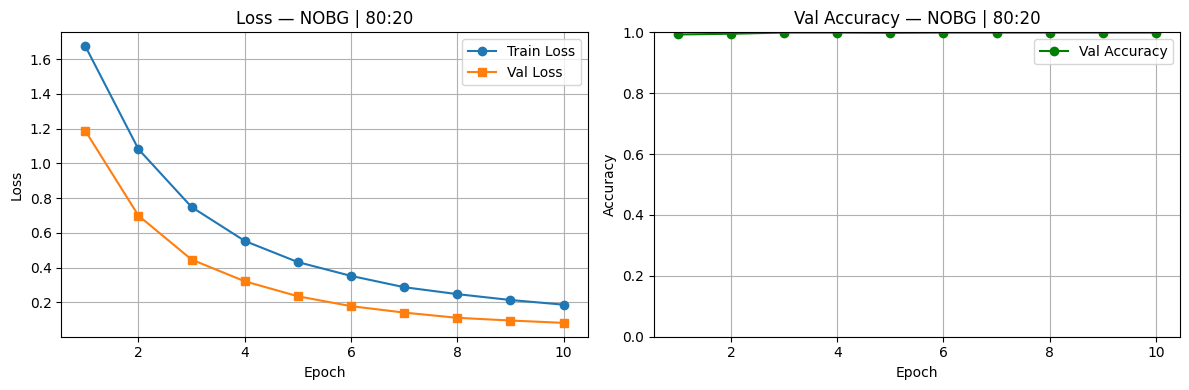

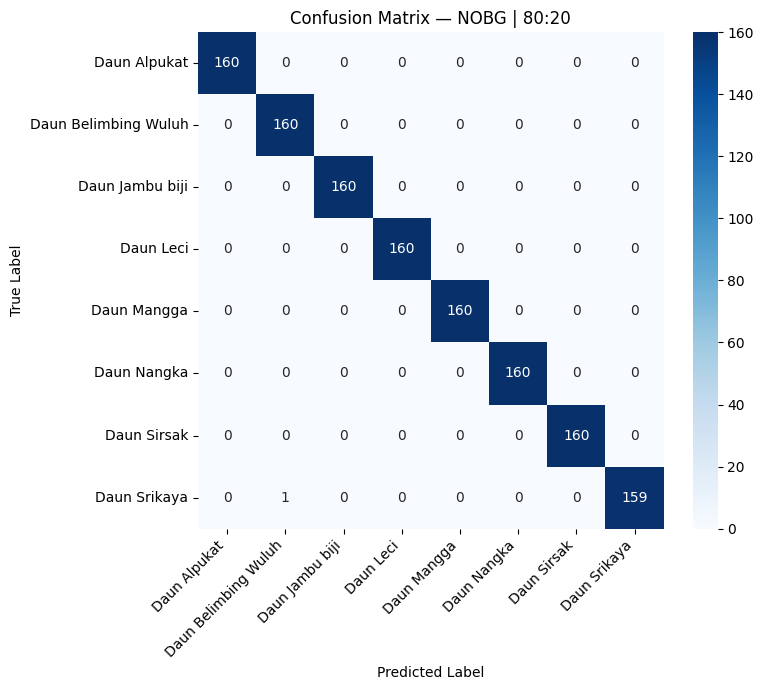

  Saved → results_nobg_80.json

NOBG | Split 70:30 | 8 kelas | Train=4480 Val=1920
  Epoch 1/10  train_loss=1.7251  val_loss=1.2761  val_acc=0.9917
  Epoch 2/10  train_loss=1.1707  val_loss=0.8065  val_acc=0.9891
  Epoch 3/10  train_loss=0.8335  val_loss=0.5265  val_acc=0.9969
  Epoch 4/10  train_loss=0.6284  val_loss=0.3730  val_acc=0.9958
  Epoch 5/10  train_loss=0.4976  val_loss=0.2746  val_acc=0.9969
  Epoch 6/10  train_loss=0.4047  val_loss=0.2152  val_acc=0.9979
  Epoch 7/10  train_loss=0.3323  val_loss=0.1827  val_acc=0.9953
  Epoch 8/10  train_loss=0.2903  val_loss=0.1465  val_acc=0.9984
  Epoch 9/10  train_loss=0.2509  val_loss=0.1168  val_acc=0.9990
  Epoch 10/10  train_loss=0.2234  val_loss=0.1061  val_acc=0.9990
  Selesai dalam 11m 40s
                      precision    recall  f1-score   support

        Daun Alpukat       1.00      1.00      1.00       240
Daun Belimbing Wuluh       0.99      1.00      1.00       240
     Daun Jambu biji       1.00      1.00      1.00    

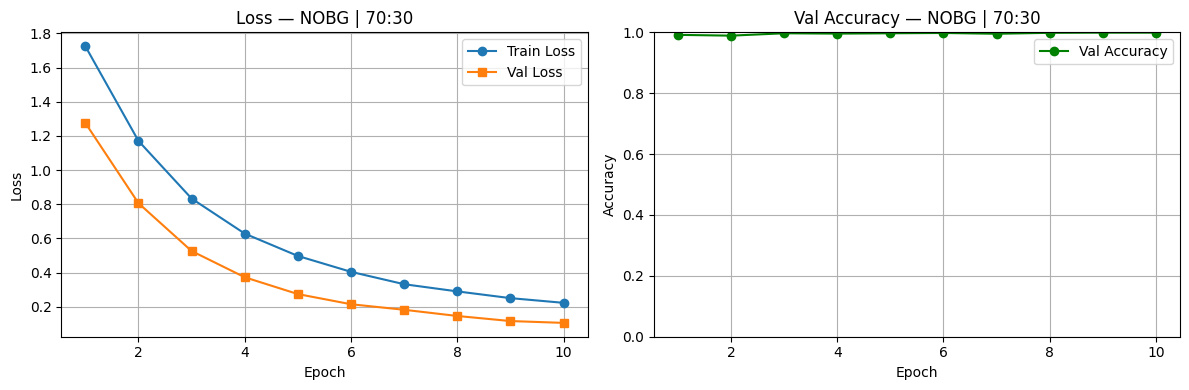

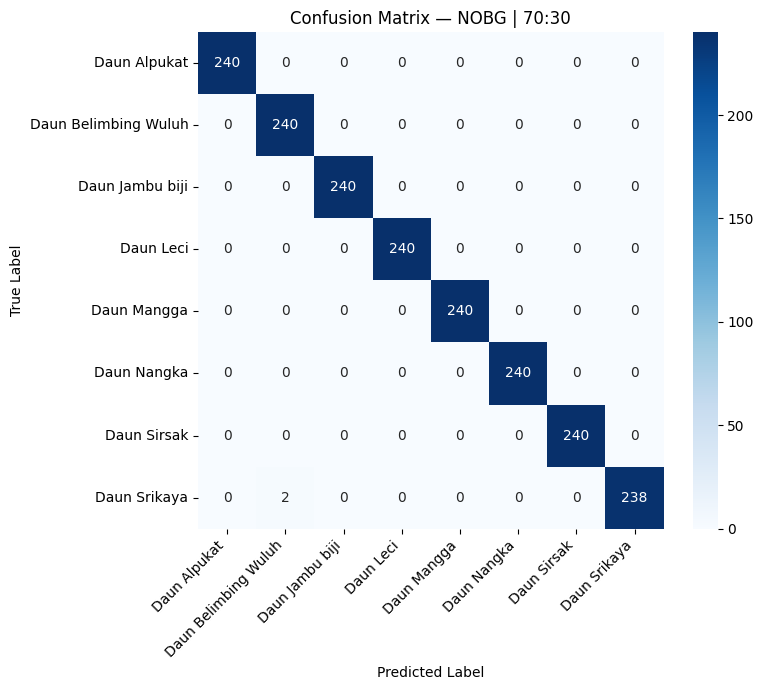

  Saved → results_nobg_70.json

BG | Split 80:20 | 8 kelas | Train=5120 Val=1280
  Epoch 1/10  train_loss=1.6798  val_loss=1.2758  val_acc=0.9781
  Epoch 2/10  train_loss=1.1035  val_loss=0.8232  val_acc=0.9898
  Epoch 3/10  train_loss=0.7769  val_loss=0.5708  val_acc=0.9875
  Epoch 4/10  train_loss=0.5829  val_loss=0.4252  val_acc=0.9828
  Epoch 5/10  train_loss=0.4613  val_loss=0.3165  val_acc=0.9914
  Epoch 6/10  train_loss=0.3749  val_loss=0.2561  val_acc=0.9891
  Epoch 7/10  train_loss=0.3093  val_loss=0.2094  val_acc=0.9945
  Epoch 8/10  train_loss=0.2674  val_loss=0.1734  val_acc=0.9984
  Epoch 9/10  train_loss=0.2296  val_loss=0.1452  val_acc=0.9953
  Epoch 10/10  train_loss=0.1954  val_loss=0.1280  val_acc=0.9930
  Selesai dalam 13m 6s
                      precision    recall  f1-score   support

        Daun Alpukat       1.00      0.95      0.97       160
Daun Belimbing Wuluh       0.99      1.00      1.00       160
     Daun Jambu biji       1.00      1.00      1.00       

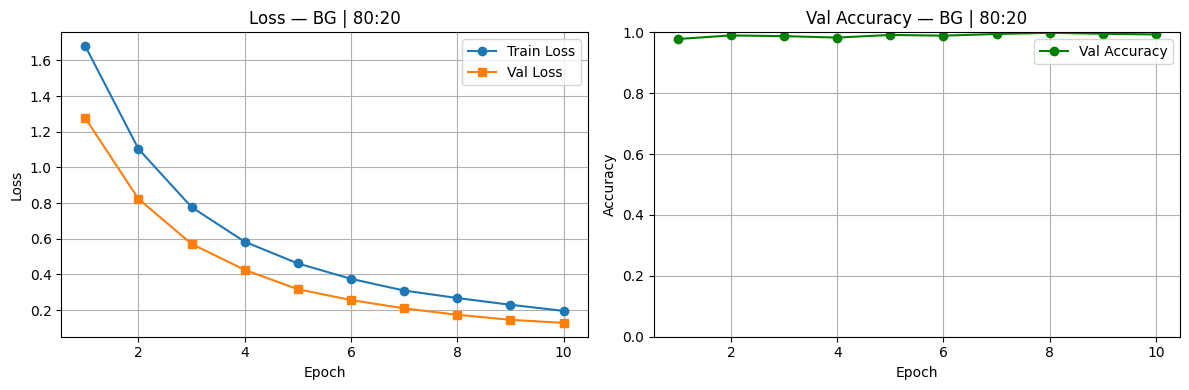

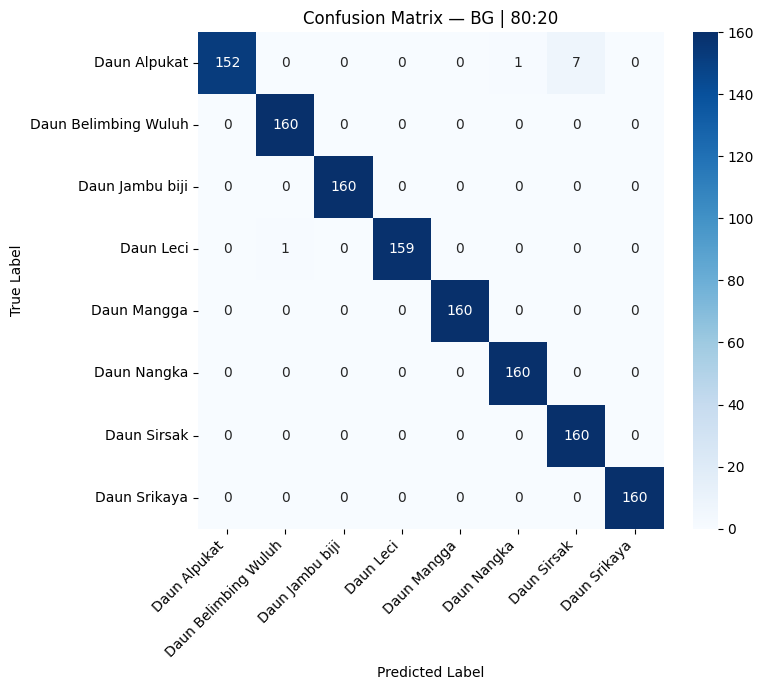

  Saved → results_bg_80.json

BG | Split 70:30 | 8 kelas | Train=4480 Val=1920
  Epoch 1/10  train_loss=1.7152  val_loss=1.3344  val_acc=0.9964
  Epoch 2/10  train_loss=1.1841  val_loss=0.8958  val_acc=0.9823
  Epoch 3/10  train_loss=0.8565  val_loss=0.6590  val_acc=0.9833
  Epoch 4/10  train_loss=0.6675  val_loss=0.4835  val_acc=0.9849
  Epoch 5/10  train_loss=0.5203  val_loss=0.3766  val_acc=0.9885
  Epoch 6/10  train_loss=0.4329  val_loss=0.3152  val_acc=0.9901
  Epoch 7/10  train_loss=0.3579  val_loss=0.2527  val_acc=0.9948
  Epoch 8/10  train_loss=0.3057  val_loss=0.2088  val_acc=0.9958
  Epoch 9/10  train_loss=0.2667  val_loss=0.1751  val_acc=0.9984
  Epoch 10/10  train_loss=0.2303  val_loss=0.1542  val_acc=0.9958
  Selesai dalam 12m 1s
                      precision    recall  f1-score   support

        Daun Alpukat       1.00      0.97      0.99       240
Daun Belimbing Wuluh       1.00      1.00      1.00       240
     Daun Jambu biji       1.00      1.00      1.00       24

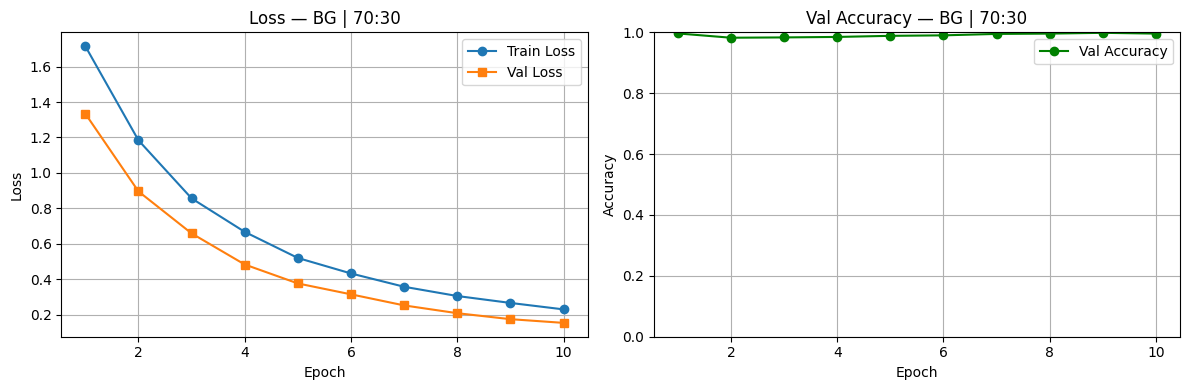

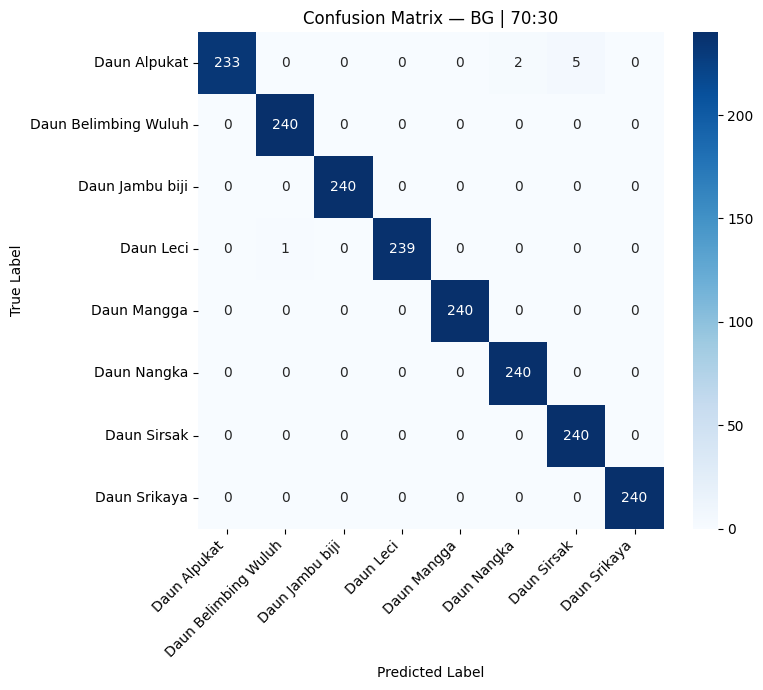

  Saved → results_bg_70.json


In [8]:
def train_and_evaluate_s1(ds_path: Path, exp_name: str, split_ratio: float):
    test_ratio = round(1.0 - split_ratio, 10)
    train_pct  = round(split_ratio * 100)
    test_pct   = 100 - train_pct
    label_str  = f"{train_pct}:{test_pct}"

    full_ds, class_names = load_species_only(ds_path)
    num_classes = len(class_names)
    all_labels  = np.array([lbl for _, lbl in full_ds.samples])

    splitter = StratifiedShuffleSplit(n_splits=1, test_size=test_ratio, random_state=SEED)
    train_idx, val_idx = next(splitter.split(np.zeros(len(all_labels)), all_labels))

    train_loader = DataLoader(
        TransformWrapper(Subset(full_ds, train_idx), transform_train_s1),
        batch_size=BATCH_SIZE, shuffle=True, num_workers=0,
    )
    val_loader = DataLoader(
        TransformWrapper(Subset(full_ds, val_idx), transform_val),
        batch_size=BATCH_SIZE, shuffle=False, num_workers=0,
    )

    model = models.shufflenet_v2_x1_0(weights=models.ShuffleNet_V2_X1_0_Weights.IMAGENET1K_V1)
    for p in model.parameters():
        p.requires_grad = False
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    model.to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.fc.parameters(), lr=LR)

    history = []
    start = time.time()
    print(f"\n{exp_name.upper()} | Split {label_str} | {num_classes} kelas | Train={len(train_idx)} Val={len(val_idx)}")

    for epoch in range(EPOCHS):
        model.train()
        running_loss = 0.0
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        avg_loss = running_loss / len(train_loader)

        model.eval()
        correct, total, val_loss = 0, 0, 0.0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                out = model(x)
                val_loss += criterion(out, y).item()
                _, preds = torch.max(out, 1)
                correct += (preds == y).sum().item()
                total   += y.size(0)
        val_acc = correct / total

        history.append({
            "epoch": epoch+1,
            "train_loss": round(avg_loss, 4),
            "val_loss": round(val_loss / len(val_loader), 4),
            "val_acc": round(val_acc, 4),
        })
        print(f"  Epoch {epoch+1}/{EPOCHS}  train_loss={avg_loss:.4f}  val_loss={val_loss/len(val_loader):.4f}  val_acc={val_acc:.4f}")

    elapsed = time.time() - start
    print(f"  Selesai dalam {int(elapsed//60)}m {int(elapsed%60)}s")

    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for x, y in val_loader:
            _, preds = torch.max(model(x.to(DEVICE)), 1)
            y_true.extend(y.numpy())
            y_pred.extend(preds.cpu().numpy())

    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
    print(classification_report(y_true, y_pred, target_names=class_names))

    # Plot
    ep = [h["epoch"] for h in history]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(ep, [h["train_loss"] for h in history], "o-", label="Train Loss")
    ax1.plot(ep, [h["val_loss"]   for h in history], "s-", label="Val Loss")
    ax1.set_title(f"Loss — {exp_name.upper()} | {label_str}"); ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss"); ax1.legend(); ax1.grid(True)
    ax2.plot(ep, [h["val_acc"] for h in history], "o-", color="green", label="Val Accuracy")
    ax2.set_title(f"Val Accuracy — {exp_name.upper()} | {label_str}"); ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy"); ax2.set_ylim(0, 1); ax2.legend(); ax2.grid(True)
    plt.tight_layout()
    plt.savefig(RESULT_DIR / f"plot_{exp_name}_{train_pct}.png", dpi=120, bbox_inches="tight")
    plt.show()

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    fig_sz = max(8, num_classes)
    plt.figure(figsize=(fig_sz, fig_sz - 1))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.title(f"Confusion Matrix — {exp_name.upper()} | {label_str}")
    plt.ylabel("True Label"); plt.xlabel("Predicted Label")
    plt.xticks(rotation=45, ha="right"); plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(RESULT_DIR / f"cm_{exp_name}_{train_pct}.png", dpi=150, bbox_inches="tight")
    plt.show()

    torch.save(model.state_dict(), MODEL_DIR / f"shufflenet_{exp_name}_{train_pct}.pth")
    json_path = RESULT_DIR / f"results_{exp_name}_{train_pct}.json"
    json_path.write_text(json.dumps({
        "experiment": exp_name, "split": label_str,
        "dataset": str(ds_path), "num_classes": num_classes,
        "class_names": class_names, "epochs": EPOCHS,
        "training_time_sec": round(elapsed, 2),
        "final_val_accuracy": history[-1]["val_acc"],
        "classification_report": report,
        "training_history": history,
    }, indent=2, ensure_ascii=False))
    print(f"  Saved → {json_path.name}")


DATASETS_S1 = {"nobg": FINAL_NOBG, "bg": FINAL_BG}
for exp_name, ds_path in DATASETS_S1.items():
    if not ds_path.exists():
        print(f"Skip {exp_name} — {ds_path} tidak ditemukan")
        continue
    for ratio in [0.8, 0.7]:
        train_and_evaluate_s1(ds_path, exp_name, ratio)

## 6. Skenario 2 — Kondisi Daun: Sehat vs Rusak

Label ditentukan dari nama folder: folder mengandung kata "rusak" (case-insensitive) → label 1 (rusak).
Dataset: `data/resized` (termasuk semua folder, tidak dikecualikan).
Augmentasi tambahan: **GaussianBlur** untuk robustness terhadap daun lebih rusak dari dataset.

Dataset S2: 4800 | sehat=2400 rusak=2400
Train 80%: 3840 | Val 20%: 960

Training Skenario 2 | device=cpu | epochs=10
  Epoch 1/10  loss=0.6581  val_acc=0.7167
  Epoch 2/10  loss=0.6005  val_acc=0.7135
  Epoch 3/10  loss=0.5614  val_acc=0.7406
  Epoch 4/10  loss=0.5246  val_acc=0.7885
  Epoch 5/10  loss=0.4954  val_acc=0.7542
  Epoch 6/10  loss=0.4703  val_acc=0.7719
  Epoch 7/10  loss=0.4528  val_acc=0.8052
  Epoch 8/10  loss=0.4314  val_acc=0.7948
  Epoch 9/10  loss=0.4194  val_acc=0.8156
  Epoch 10/10  loss=0.4095  val_acc=0.8219
Selesai dalam 10m 15s
              precision    recall  f1-score   support

       sehat       0.90      0.72      0.80       480
       rusak       0.77      0.92      0.84       480

    accuracy                           0.82       960
   macro avg       0.83      0.82      0.82       960
weighted avg       0.83      0.82      0.82       960



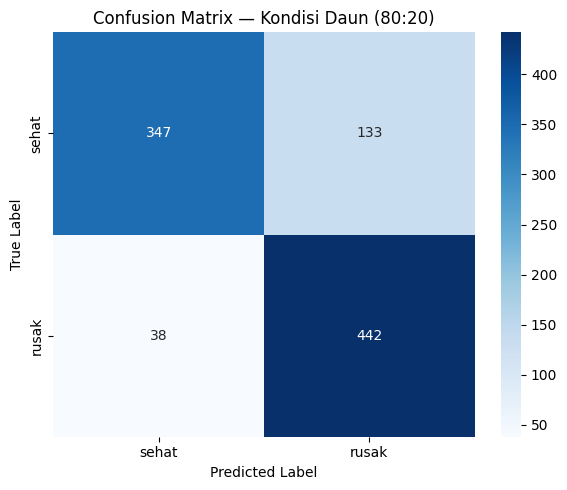

Model & JSON Skenario 2 disimpan.


In [9]:
class LeafConditionDataset(Dataset):
    VALID_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

    def __init__(self, root_dir: Path):
        self.samples: list[tuple[Path, int]] = []
        for folder in sorted(root_dir.iterdir()):
            if not folder.is_dir():
                continue
            label = 1 if "rusak" in folder.name.lower() else 0
            for img_file in folder.iterdir():
                if img_file.suffix.lower() in self.VALID_EXTS:
                    self.samples.append((img_file, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        return Image.open(img_path).convert("RGB"), label

    def get_labels(self):
        return [lbl for _, lbl in self.samples]


CLASS_NAMES_S2 = ["sehat", "rusak"]
TRAIN_RATIO_S2 = 0.8
train_pct_s2   = round(TRAIN_RATIO_S2 * 100)
test_pct_s2    = 100 - train_pct_s2

full_ds_s2 = LeafConditionDataset(RESIZED_DIR)
labels_s2  = np.array(full_ds_s2.get_labels())

splitter_s2 = StratifiedShuffleSplit(n_splits=1, test_size=round(1.0 - TRAIN_RATIO_S2, 10), random_state=SEED)
train_idx_s2, val_idx_s2 = next(splitter_s2.split(np.zeros(len(labels_s2)), labels_s2))

train_loader_s2 = DataLoader(
    TransformWrapper(Subset(full_ds_s2, train_idx_s2), transform_train_s2),
    batch_size=BATCH_SIZE, shuffle=True, num_workers=0,
)
val_loader_s2 = DataLoader(
    TransformWrapper(Subset(full_ds_s2, val_idx_s2), transform_val),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=0,
)

print(f"Dataset S2: {len(full_ds_s2)} | sehat={int((labels_s2==0).sum())} rusak={int((labels_s2==1).sum())}")
print(f"Train {train_pct_s2}%: {len(train_idx_s2)} | Val {test_pct_s2}%: {len(val_idx_s2)}")

model_s2 = models.shufflenet_v2_x1_0(weights=models.ShuffleNet_V2_X1_0_Weights.IMAGENET1K_V1)
for p in model_s2.parameters():
    p.requires_grad = False
model_s2.fc = nn.Linear(model_s2.fc.in_features, len(CLASS_NAMES_S2))
model_s2.to(DEVICE)

criterion_s2 = nn.CrossEntropyLoss()
optimizer_s2 = torch.optim.Adam(model_s2.fc.parameters(), lr=LR)

history_s2 = []
start_s2 = time.time()
print(f"\nTraining Skenario 2 | device={DEVICE} | epochs={EPOCHS}")

for epoch in range(EPOCHS):
    model_s2.train()
    running_loss = 0.0
    for x, y in train_loader_s2:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer_s2.zero_grad()
        loss = criterion_s2(model_s2(x), y)
        loss.backward()
        optimizer_s2.step()
        running_loss += loss.item()
    avg_loss = running_loss / len(train_loader_s2)

    model_s2.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in val_loader_s2:
            x, y = x.to(DEVICE), y.to(DEVICE)
            _, preds = torch.max(model_s2(x), 1)
            correct += (preds == y).sum().item()
            total   += y.size(0)
    val_acc = correct / total
    history_s2.append({"epoch": epoch+1, "loss": round(avg_loss, 4), "val_acc": round(val_acc, 4)})
    print(f"  Epoch {epoch+1}/{EPOCHS}  loss={avg_loss:.4f}  val_acc={val_acc:.4f}")

elapsed_s2 = time.time() - start_s2
print(f"Selesai dalam {int(elapsed_s2//60)}m {int(elapsed_s2%60)}s")

model_s2.eval()
y_true_s2, y_pred_s2 = [], []
with torch.no_grad():
    for x, y in val_loader_s2:
        _, preds = torch.max(model_s2(x.to(DEVICE)), 1)
        y_true_s2.extend(y.numpy())
        y_pred_s2.extend(preds.cpu().numpy())

report_s2 = classification_report(y_true_s2, y_pred_s2, target_names=CLASS_NAMES_S2, output_dict=True)
print(classification_report(y_true_s2, y_pred_s2, target_names=CLASS_NAMES_S2))

cm_s2 = confusion_matrix(y_true_s2, y_pred_s2)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_s2, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES_S2, yticklabels=CLASS_NAMES_S2)
plt.title(f"Confusion Matrix — Kondisi Daun ({train_pct_s2}:{test_pct_s2})")
plt.ylabel("True Label"); plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig(RESULT_DIR / "cm_condition.png", dpi=150, bbox_inches="tight")
plt.show()

torch.save(model_s2.state_dict(), MODEL_DIR / "shufflenet_condition.pth")
(RESULT_DIR / "results_condition.json").write_text(json.dumps({
    "experiment": "kondisi_daun", "dataset": str(RESIZED_DIR),
    "split": f"{train_pct_s2}:{test_pct_s2}",
    "train_augmentation": ["RandomRotate90(0/90/180/270)", "GaussianBlur(k=3)", "RandomHorizontalFlip"],
    "epochs": EPOCHS, "training_time_sec": round(elapsed_s2, 2),
    "final_val_accuracy": history_s2[-1]["val_acc"],
    "classification_report": report_s2,
    "training_history": history_s2,
}, indent=2, ensure_ascii=False))
print("Model & JSON Skenario 2 disimpan.")

## 7. Ringkasan Hasil

In [10]:
print("=== MODEL FILES ===")
for f in sorted(MODEL_DIR.glob("*.pth")):
    print(f"  {f.name}")

print("\n=== RESULT JSON ===")
for f in sorted(RESULT_DIR.glob("*.json")):
    data = json.loads(f.read_text(encoding="utf-8"))
    acc  = data.get("final_val_accuracy", "N/A")
    print(f"  {f.name:<35} val_acc={acc}")

print("\n=== PLOTS ===")
for f in sorted(RESULT_DIR.glob("*.png")):
    print(f"  {f.name}")

=== MODEL FILES ===
  shufflenet_bg_70.pth
  shufflenet_bg_80.pth
  shufflenet_condition.pth
  shufflenet_nobg_70.pth
  shufflenet_nobg_80.pth

=== RESULT JSON ===
  results_bg_70.json                  val_acc=0.9958
  results_bg_80.json                  val_acc=0.993
  results_condition.json              val_acc=0.8219
  results_nobg_70.json                val_acc=0.999
  results_nobg_80.json                val_acc=0.9992

=== PLOTS ===
  cm_bg_70.png
  cm_bg_80.png
  cm_condition.png
  cm_nobg_70.png
  cm_nobg_80.png
  plot_bg_70.png
  plot_bg_80.png
  plot_nobg_70.png
  plot_nobg_80.png
